<a href="https://colab.research.google.com/github/gaikwadritik741-sys/MDM-ML/blob/main/ML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/wireless_signal_quality_dataset.csv")
print("First Five Records")
print(data.head())
print("\nDataset Shape:", data.shape)

First Five Records
   Signal_Strength_dBm  SNR_dB  Interference_dB  Distance_m  Frequency_GHz  \
0                  -41       6                0         257            5.0   
1                  -86      25               20         134            2.4   
2                  -73      27                0         385            2.4   
3                  -57       5                0         255            5.0   
4                  -87      15               24          61            5.0   

   Channel_Bandwidth_MHz  Noise_Floor_dBm  Connected_Devices  \
0                    160             -100                 24   
1                    160              -96                 41   
2                     20              -72                 13   
3                    160              -86                  9   
4                     20              -79                 32   

   Estimated_Throughput_Mbps Quality  
0                         18    Poor  
1                         55    Poor  
2         

In [ ]:
X = data.drop("Quality", axis=1)
y = data["Quality"]

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("\nClass Labels:")
print(encoder.classes_)


Class Labels:
[0 1 2 3]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.25,
random_state=42,
stratify=y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
criterion='gini',
max_depth=5,
random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy : {:.2f}%".format(accuracy * 100))


Accuracy : 92.00%


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[ 0  0  1  0]
 [ 0  8  1  0]
 [ 0  0  2  0]
 [ 0  0  0 13]]


In [ ]:
print("\nClassification Report")
print(classification_report(
y_test,
y_pred,
target_names=encoder.classes_.astype(str)
))


Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.89      0.94         9
           2       0.50      1.00      0.67         2
           3       1.00      1.00      1.00        13

    accuracy                           0.92        25
   macro avg       0.62      0.72      0.65        25
weighted avg       0.92      0.92      0.91        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
importance = pd.Series(
dt.feature_importances_,
index=X.columns
)
importance = importance.sort_values(ascending=False)
print("\nFeature Importance")
print(importance)


Feature Importance
Signal_Strength_dBm          0.438873
SNR_dB                       0.365448
Estimated_Throughput_Mbps    0.117036
Interference_dB              0.078643
Distance_m                   0.000000
Frequency_GHz                0.000000
Channel_Bandwidth_MHz        0.000000
Noise_Floor_dBm              0.000000
Connected_Devices            0.000000
dtype: float64


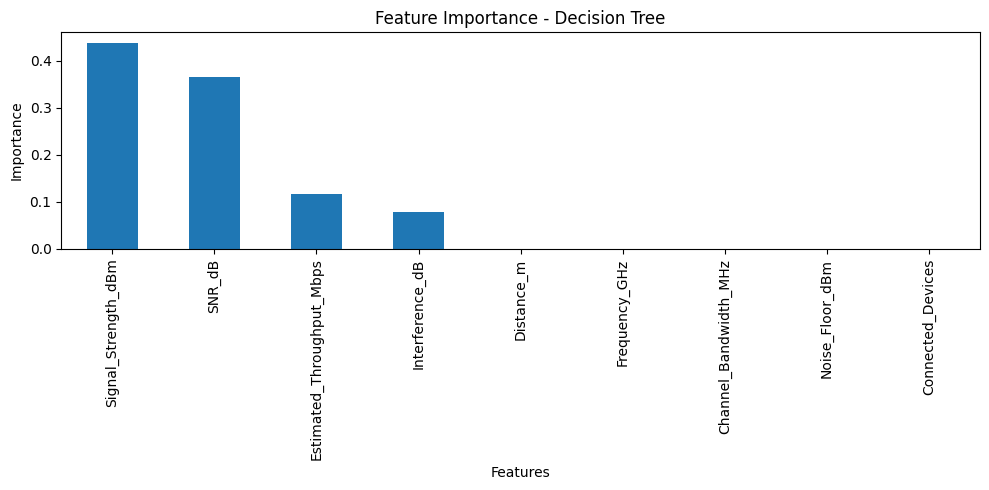

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
importance.plot(kind='bar')
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()

Text(0.5, 1.0, 'Decision Tree for Fault Detection')

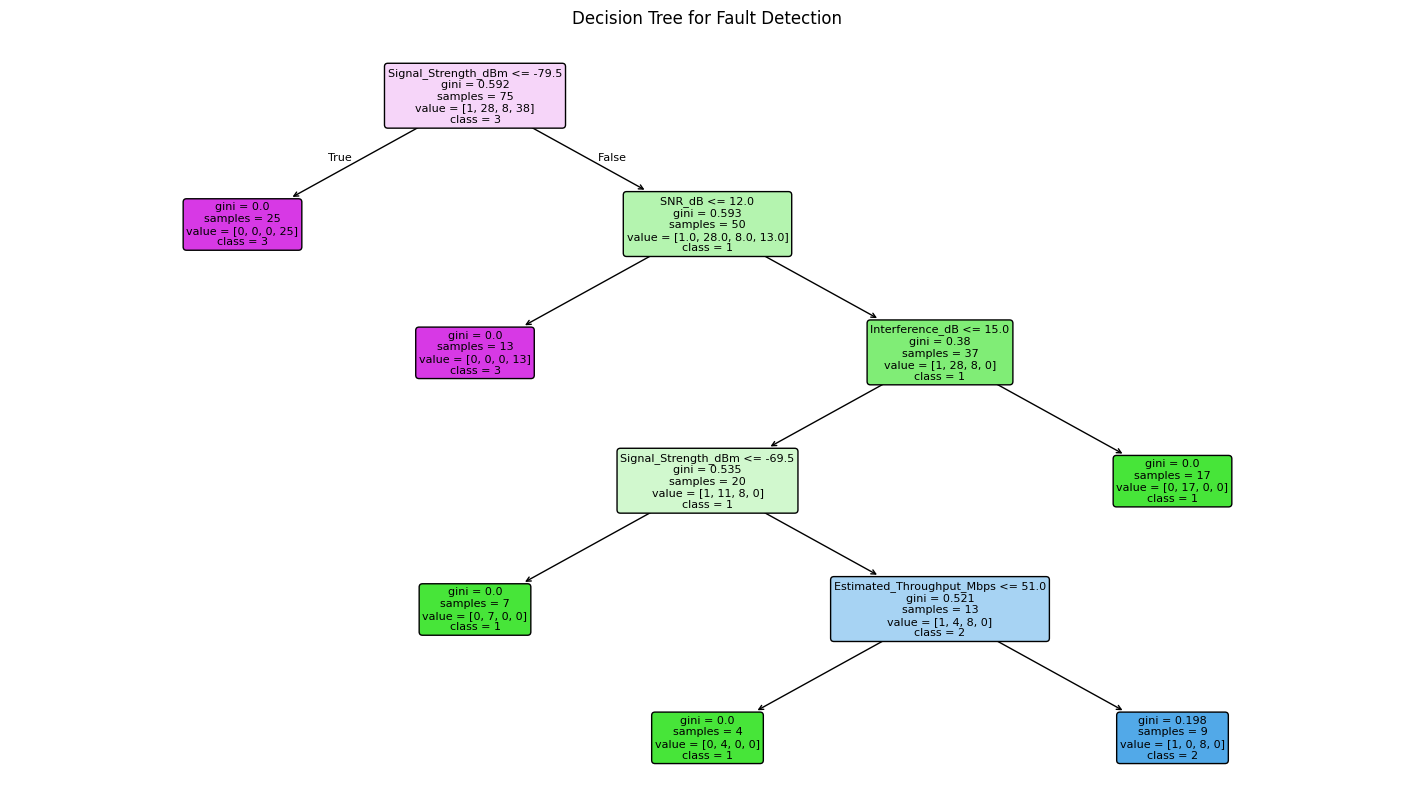

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
dt,
feature_names=X.columns,
class_names=encoder.classes_.astype(str),
filled=True,
rounded=True,
fontsize=8
)
plt.title("Decision Tree for Fault Detection")